# 1. Librerías

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para que los gráficos sean más estéticps
sns.set_theme(style="whitegrid")


# 2. Carga de datos

In [17]:
# 1. Cargamos los archivos
esp = pd.read_csv('ESPAÑA.csv', sep=';')
eur = pd.read_csv('EUROPA.csv', sep=';')



## 2.1 Inspección inicial — España

In [18]:
# 2. Vistazo rápido a los datos de España
print("--- PRIMERAS FILAS DE ESPAÑA ---")
print(esp.head())

# 3. Ver qué tipo de datos
print("\n--- INFORMACIÓN TÉCNICA ---")
print(esp.info())

--- PRIMERAS FILAS DE ESPAÑA ---
    año  empleo desempleo actividad absentismo_enf_acc absentismo_total  \
0  2009  61,93%    17,09%    74,69%              0,61%            2,29%   
1  2010  60,71%    19,36%    75,28%              0,59%            2,23%   
2  2011  59,72%    21,22%    75,80%              0,56%            2,08%   
3  2012  57,26%    24,96%    76,31%              0,50%            2,07%   
4  2013  56,07%    26,64%    76,43%              0,50%            2,06%   

  parados_corta_dur parados_larga_dur horas_trabajadas horas_hab_trabajadas  \
0            69,14%            30,86%             34,7                 38,6   
1            54,03%            45,97%           34,525                 38,5   
2            48,18%            51,82%             34,4                 38,3   
3            44,40%            55,60%           34,075                   38   
4            38,04%            61,96%            34,05                 37,9   

  coste_laboral empleo_yoy desempleo_yoy 

## 2.2 Inspección inicial — Europa

In [19]:
# 2. Vistazo rápido a los datos de EUROPA
print("--- PRIMERAS FILAS DE EUROPA ---")
print(eur.head())

# 3. Ver qué tipo de datos
print("\n--- INFORMACIÓN TÉCNICA ---")
print(eur.info())

--- PRIMERAS FILAS DE EUROPA ---
      pais   año  empleo desempleo actividad absentismo parados_larga_dur  \
0  Austria  2009  73,40%     4,10%    77,50%     11,88%            25,80%   
1  Austria  2010  73,90%     3,80%    77,70%     11,70%            30,50%   
2  Austria  2011  74,20%     3,60%    77,80%     11,55%            31,30%   
3  Austria  2012  74,40%     3,90%    78,30%     12,00%            29,60%   
4  Austria  2013  74,60%     4,30%    78,90%     12,33%            28,90%   

   horas_hab_trabajadas poblacion_neet empleo_yoy desempleo_yoy actividad_yoy  \
0                    38         10,00%        NaN           NaN           NaN   
1                    38          9,50%      0,68%        -7,32%         0,26%   
2                    38          8,90%      0,41%        -5,26%         0,13%   
3                    38          8,60%      0,27%         8,33%         0,64%   
4                    37          9,00%      0,27%        10,26%         0,77%   

  absentismo_yoy 

In [20]:
# Validación de Unicidad y Nulos
print("--- VALIDACIÓN DE DATOS ESPAÑA ---")
print(f"Duplicados: {esp.duplicated().sum()}")
print(f"Valores Nulos:\n{esp.isnull().sum()}")

print("\n--- VALIDACIÓN DE DATOS EUROPA ---")
print(f"Duplicados: {eur.duplicated().sum()}")
print(f"Valores Nulos:\n{eur.isnull().sum()}")

--- VALIDACIÓN DE DATOS ESPAÑA ---
Duplicados: 0
Valores Nulos:
año                         0
empleo                      0
desempleo                   0
actividad                   0
absentismo_enf_acc          0
absentismo_total            0
parados_corta_dur           0
parados_larga_dur           0
horas_trabajadas            0
horas_hab_trabajadas        0
coste_laboral               0
empleo_yoy                  1
desempleo_yoy               1
actividad_yoy               1
absentismo_enf_acc_yoy      1
absentismo_total_yoy        1
parados_corta_dur_yoy       1
parados_larga_dur_yoy       1
horas_trabajadas_yoy        1
horas_hab_trabajadas_yoy    1
dtype: int64

--- VALIDACIÓN DE DATOS EUROPA ---
Duplicados: 0
Valores Nulos:
pais                      0
año                       0
empleo                    0
desempleo                 0
actividad                 0
absentismo                0
parados_larga_dur         0
horas_hab_trabajadas      0
poblacion_neet            0
empleo

# 3. Limpieza y transformación

In [21]:
# 1. Definimos las columnas que queremos limpiar para cada dataset
cols_espana = [
    'empleo', 'desempleo', 'actividad', 'absentismo_total',
    'horas_trabajadas', 'coste_laboral'
]

cols_europa = [
    'empleo', 'desempleo', 'actividad', 'absentismo',
    'parados_larga_dur', 'poblacion_neet'
]

# 2. Limpieza para ESPAÑA
for col in cols_espana:
    # Quitamos el % y cambiamos la coma por el punto
    esp[col] = esp[col].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
    # Convertimos a número real
    esp[col] = pd.to_numeric(esp[col], errors='coerce')

# 3. Limpieza para EUROPA
for col in cols_europa:
    eur[col] = eur[col].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
    eur[col] = pd.to_numeric(eur[col], errors='coerce')

print(" Transformación completada: % eliminados y comas cambiadas por puntos.")

# Comprobación final: ahora verás que ya no hay símbolos raros
print("\n--- Vistazo tras la transformación (España) ---")
print(esp[cols_espana].head())
print("\n--- Vistazo tras la transformación (Europa) ---")
print(eur[cols_europa].head())

✅ Transformación completada: % eliminados y comas cambiadas por puntos.

--- Vistazo tras la transformación (España) ---
   empleo  desempleo  actividad  absentismo_total  horas_trabajadas  \
0   61.93      17.09      74.69              2.29            34.700   
1   60.71      19.36      75.28              2.23            34.525   
2   59.72      21.22      75.80              2.08            34.400   
3   57.26      24.96      76.31              2.07            34.075   
4   56.07      26.64      76.43              2.06            34.050   

   coste_laboral  
0          19.05  
1          19.15  
2          19.60  
3          19.80  
4          19.91  

--- Vistazo tras la transformación (Europa) ---
   empleo  desempleo  actividad  absentismo  parados_larga_dur  poblacion_neet
0    73.4        4.1       77.5       11.88               25.8            10.0
1    73.9        3.8       77.7       11.70               30.5             9.5
2    74.2        3.6       77.8       11.55         

## 3.1 Depuración de tipos

In [22]:
# Definimos las columnas que queremos limpiar para España y Europa
cols_esp = ['empleo', 'desempleo', 'actividad', 'absentismo_total', 'horas_trabajadas', 'coste_laboral']
cols_eur = ['empleo', 'desempleo', 'actividad', 'absentismo', 'parados_larga_dur', 'poblacion_neet']

# Función para limpiar: quita %, cambia coma por punto y convierte a número
def depurar_datos(df, columnas):
    for col in columnas:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# Aplicamos la limpieza a ambos datasets
esp = depurar_datos(esp, cols_esp)
eur = depurar_datos(eur, cols_eur)

print(" Transformación completada.")
# Comprobamos que ahora sí son números (debe poner float64)
print(esp[cols_esp].info())
print(eur[cols_eur].info())

✅ Transformación completada.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   empleo            17 non-null     float64
 1   desempleo         17 non-null     float64
 2   actividad         17 non-null     float64
 3   absentismo_total  17 non-null     float64
 4   horas_trabajadas  17 non-null     float64
 5   coste_laboral     17 non-null     float64
dtypes: float64(6)
memory usage: 948.0 bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   empleo             476 non-null    float64
 1   desempleo          476 non-null    float64
 2   actividad          476 non-null    float64
 3   absentismo         476 non-null    float64
 4   parados_larga_dur  476 non-null    float64
 5 

# 4. Estadísticos descriptivos

In [23]:
# Sacamos las estadísticas descriptivas de España
print(" RESUMEN ESTADÍSTICO: ESPAÑA")
# Seleccionamos las columnas clave que ya limpiamos
columnas_clave = ['empleo', 'desempleo', 'actividad', 'absentismo_total', 'horas_trabajadas']
resumen_esp = esp[columnas_clave].describe()
print(resumen_esp)

# Sacamos las de Europa para comparar después
print("\n RESUMEN ESTADÍSTICO: EUROPA")
resumen_eur = eur[['empleo', 'desempleo', 'actividad', 'absentismo']].describe()
print(resumen_eur)

📊 RESUMEN ESTADÍSTICO: ESPAÑA
          empleo  desempleo  actividad  absentismo_total  horas_trabajadas
count  17.000000  17.000000  17.000000         17.000000         17.000000
mean   63.165882  18.241176  77.204118          2.464706         33.223529
std     4.616871   4.793977   1.478069          0.574196          1.286088
min    56.070000  11.100000  74.690000          1.950000         30.350000
25%    59.720000  15.000000  76.310000          2.070000         32.025000
50%    63.050000  17.090000  77.080000          2.200000         33.875000
75%    65.860000  21.220000  77.910000          2.900000         34.075000
max    71.220000  26.640000  80.110000          4.030000         34.700000

📊 RESUMEN ESTADÍSTICO: EUROPA
           empleo   desempleo   actividad  absentismo
count  476.000000  476.000000  476.000000  476.000000
mean    70.566176    6.383613   76.951261    8.559874
std      7.972369    3.828099    6.100935    3.930942
min     47.800000    1.600000   54.500000    0.0

In [24]:
# 1. Calculamos las medias de ambos
media_esp = esp[['absentismo_total', 'desempleo', 'empleo']].mean()
media_eur = eur[['absentismo', 'desempleo', 'empleo']].mean()

# 2. Creamos una tabla comparativa
comparativa = pd.DataFrame({
    'Variable': ['Absentismo', 'Desempleo', 'Empleo'],
    'España (%)': [media_esp['absentismo_total'], media_esp['desempleo'], media_esp['empleo']],
    'Europa (%)': [media_eur['absentismo'], media_eur['desempleo'], media_eur['empleo']]
})

print(" TABLA COMPARATIVA DE MEDIAS")
print(comparativa)

📊 TABLA COMPARATIVA DE MEDIAS
     Variable  España (%)  Europa (%)
0  Absentismo    2.464706    8.559874
1   Desempleo   18.241176    6.383613
2      Empleo   63.165882   70.566176


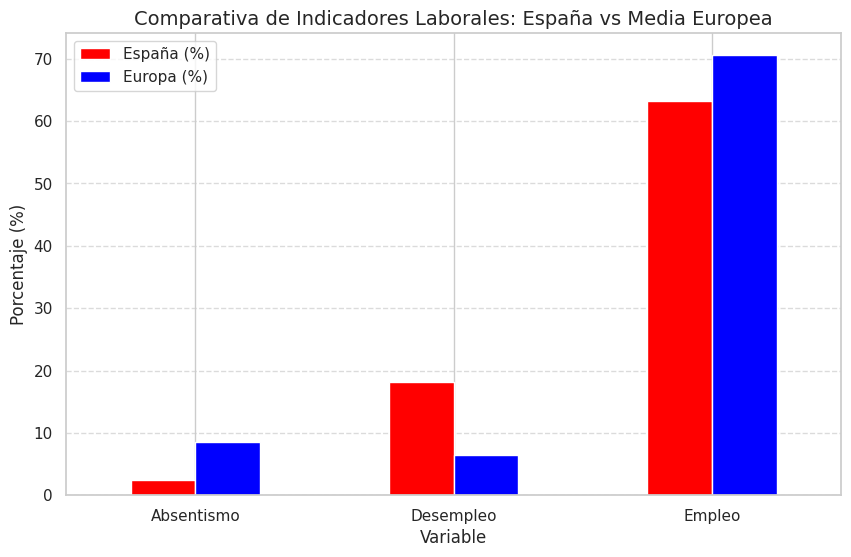

In [25]:
# Gráfico de barras comparativo
comparativa.plot(x='Variable', y=['España (%)', 'Europa (%)'], kind='bar', color=['red', 'blue'], figsize=(10,6))

plt.title('Comparativa de Indicadores Laborales: España vs Media Europea', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

📊 RESUMEN ESTADÍSTICO COMPARATIVO
     Variable  España (Media)  Europa (Media)
0  Absentismo        2.464706        8.559874
1   Desempleo       18.241176        6.383613
2      Empleo       63.165882       70.566176


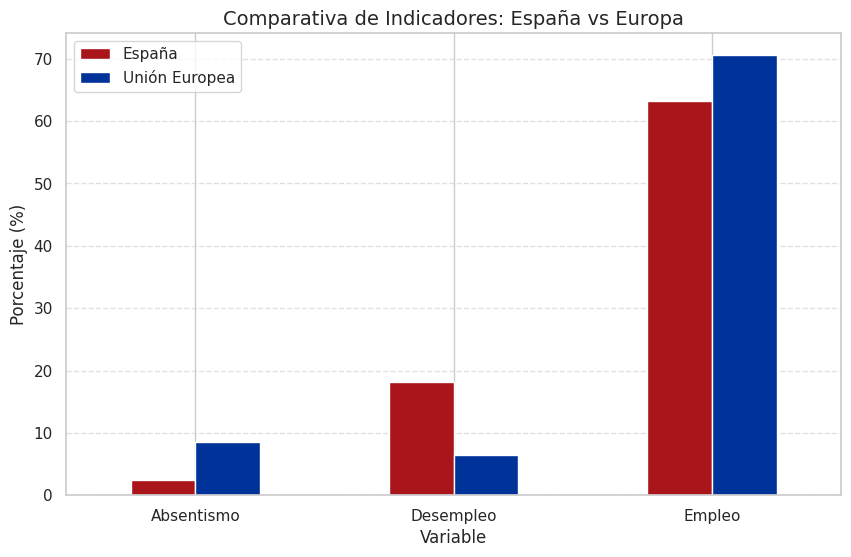

In [26]:
# 1. Obtenemos el describe de ambos y lo preparamos para comparar
resumen_esp = esp[['absentismo_total', 'desempleo', 'empleo']].describe().loc[['mean', 'std', 'min', 'max']]
resumen_eur = eur[['absentismo', 'desempleo', 'empleo']].describe().loc[['mean', 'std', 'min', 'max']]

print(" RESUMEN ESTADÍSTICO COMPARATIVO")
# Creamos una tabla que junte las medias para comparar
comparativa_medias = pd.DataFrame({
    'Variable': ['Absentismo', 'Desempleo', 'Empleo'],
    'España (Media)': [resumen_esp.loc['mean', 'absentismo_total'], resumen_esp.loc['mean', 'desempleo'], resumen_esp.loc['mean', 'empleo']],
    'Europa (Media)': [resumen_eur.loc['mean', 'absentismo'], resumen_eur.loc['mean', 'desempleo'], resumen_eur.loc['mean', 'empleo']]
})
print(comparativa_medias)

# 2. Gráfico de barras comparativo (Storytelling visual)
comparativa_medias.plot(x='Variable', y=['España (Media)', 'Europa (Media)'], kind='bar', color=['#AA151B', '#003399'], figsize=(10,6))
plt.title('Comparativa de Indicadores: España vs Europa', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.legend(['España', 'Unión Europea'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 5. Análisis de correlación

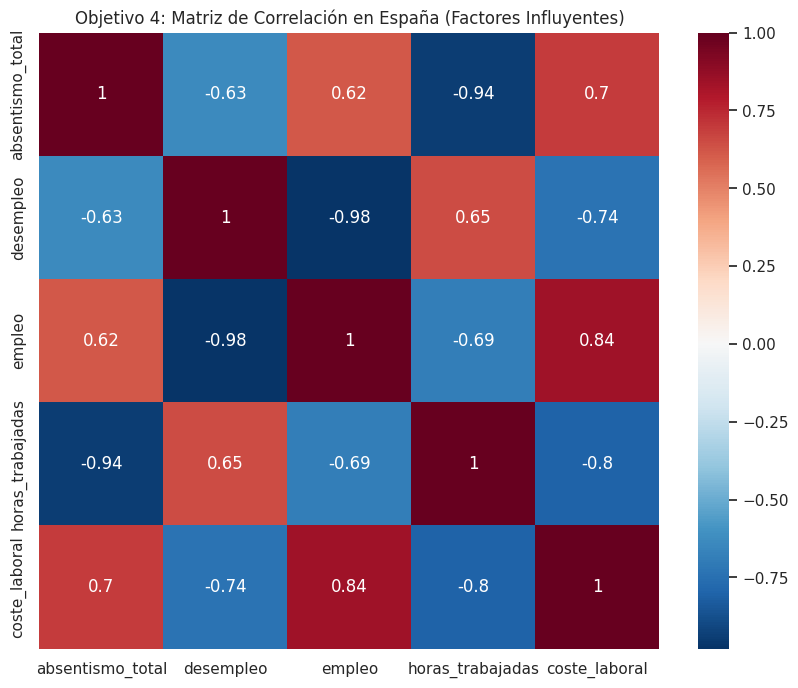

In [27]:
# Seleccionamos las variables para ver cómo se relacionan
variables_corr = ['absentismo_total', 'desempleo', 'empleo', 'horas_trabajadas', 'coste_laboral']

plt.figure(figsize=(10, 8))
# Creamos el mapa de calor (Heatmap)
sns.heatmap(esp[variables_corr].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Objetivo 4: Matriz de Correlación en España (Factores Influyentes)')
plt.show()

# 6. Pair plot

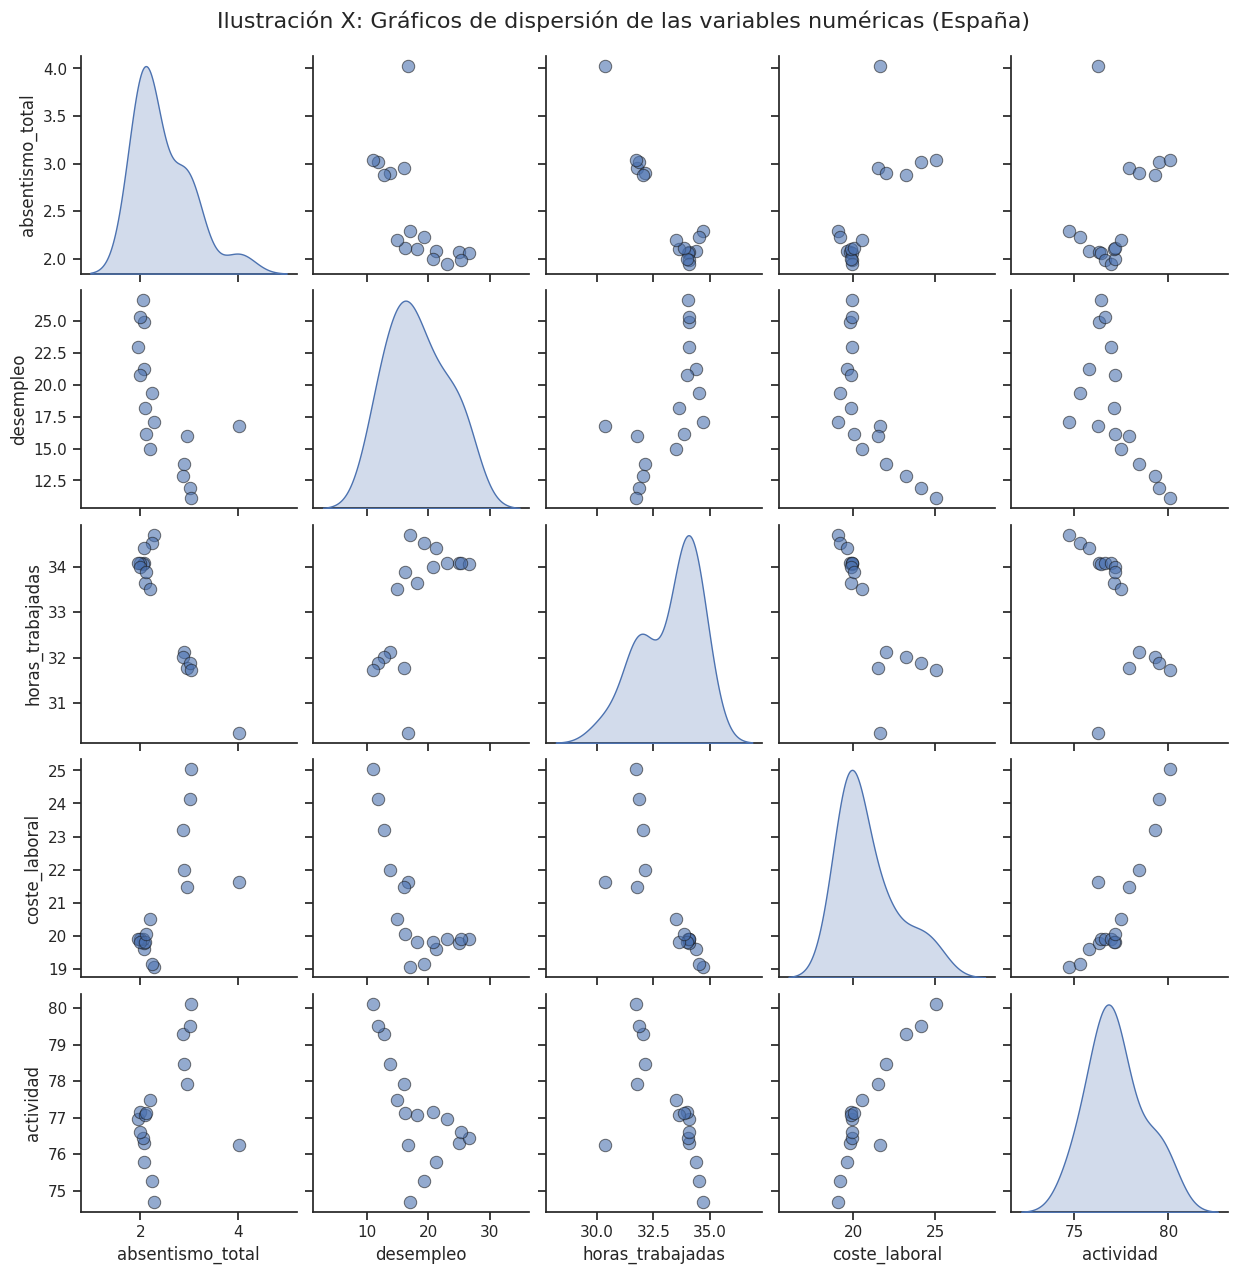

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the DataFrame again
esp = pd.read_csv('ESPAÑA.csv', sep=';')

# Define cleaning function and columns, as done previously
def depurar_datos(df, columnas):
    for col in columnas:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

cols_esp = ['empleo', 'desempleo', 'actividad', 'absentismo_total', 'horas_trabajadas', 'coste_laboral']
esp = depurar_datos(esp, cols_esp)

# Definimos las variables numéricas clave para el cruce
vars_analisis = ['absentismo_total', 'desempleo', 'horas_trabajadas', 'coste_laboral', 'actividad']

# Creamos el Pair Plot (Matriz de dispersión)
sns.set(style="ticks")
pair_plot = sns.pairplot(esp[vars_analisis], diag_kind='kde', plot_kws={'alpha':0.6, 's':80, 'edgecolor':'k'})

pair_plot.fig.suptitle('Ilustración X: Gráficos de dispersión de las variables numéricas (España)', y=1.02, fontsize=16)
plt.show()

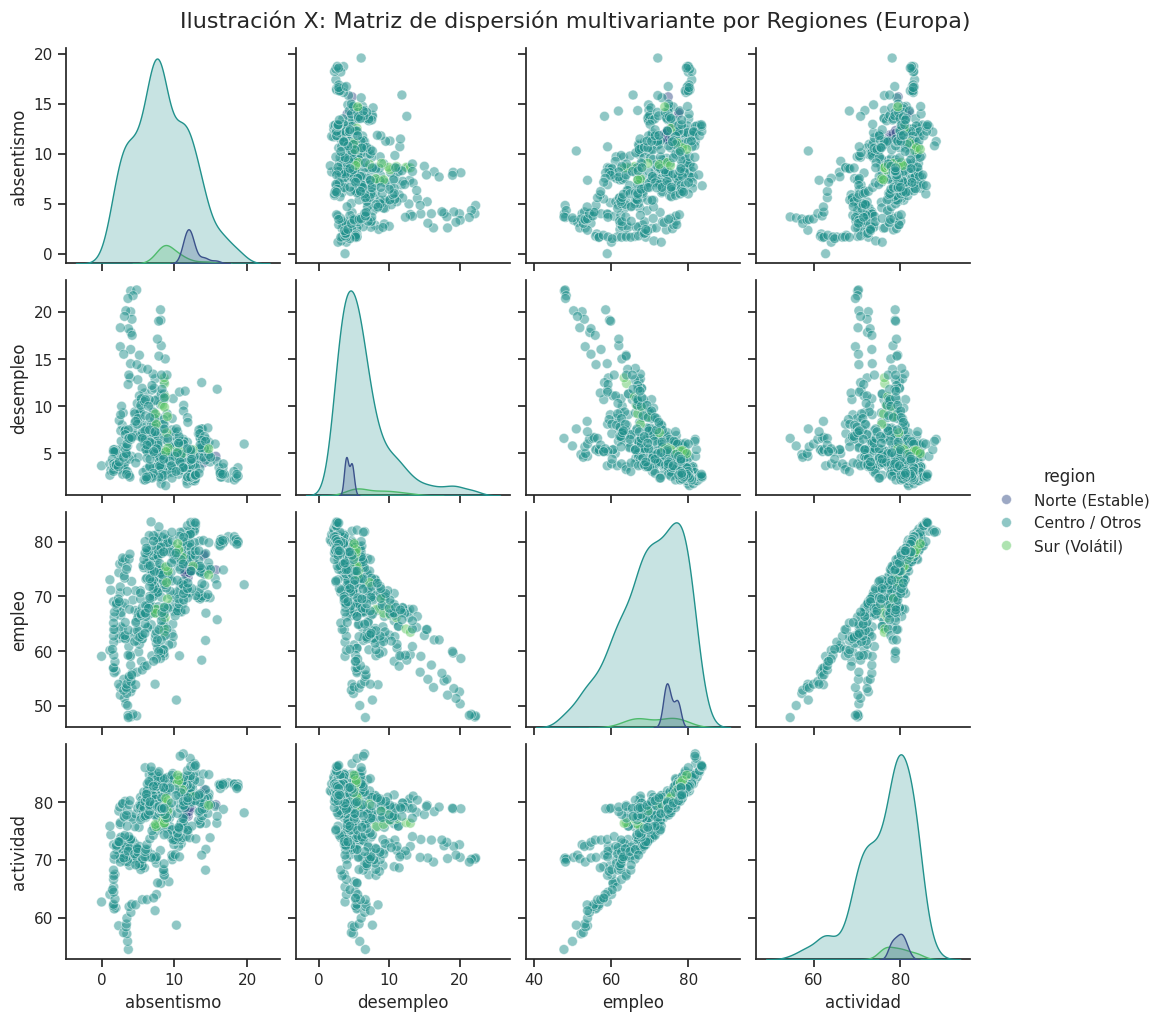

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the DataFrame again
eur = pd.read_csv('EUROPA.csv', sep=';')

# Define cleaning function (if not already defined in this scope)
def depurar_datos(df, columnas):
    for col in columnas:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

cols_eur = ['empleo', 'desempleo', 'actividad', 'absentismo', 'parados_larga_dur', 'poblacion_neet']
eur = depurar_datos(eur, cols_eur)

# Redefine region (as it was created in a previous cell that might not have run)
norte = ['Denmark', 'Finland', 'Norway', 'Sweden', 'Netherlands', 'Germany', 'Austria']
sur = ['Spain', 'Italy', 'Portugal', 'Greece', 'Cyprus']

def categorizar_region(pais):
    if pais in norte: return 'Norte (Estable)'
    if pais in sur: return 'Sur (Volátil)'
    return 'Centro / Otros'

eur['region'] = eur['pais'].apply(categorizar_region)

# Definimos las variables numéricas de Europa
vars_eur = ['absentismo', 'desempleo', 'empleo', 'actividad']

# Creamos el Pair Plot coloreado por REGIONES
sns.set(style="ticks")
pair_eur = sns.pairplot(eur, vars=vars_eur, hue='region',
                        palette='viridis', diag_kind='kde',
                        plot_kws={'alpha':0.5, 's':50})

pair_eur.fig.suptitle('Ilustración X: Matriz de dispersión multivariante por Regiones (Europa)', y=1.02, fontsize=16)
plt.show()

# 7. Detección de outliers

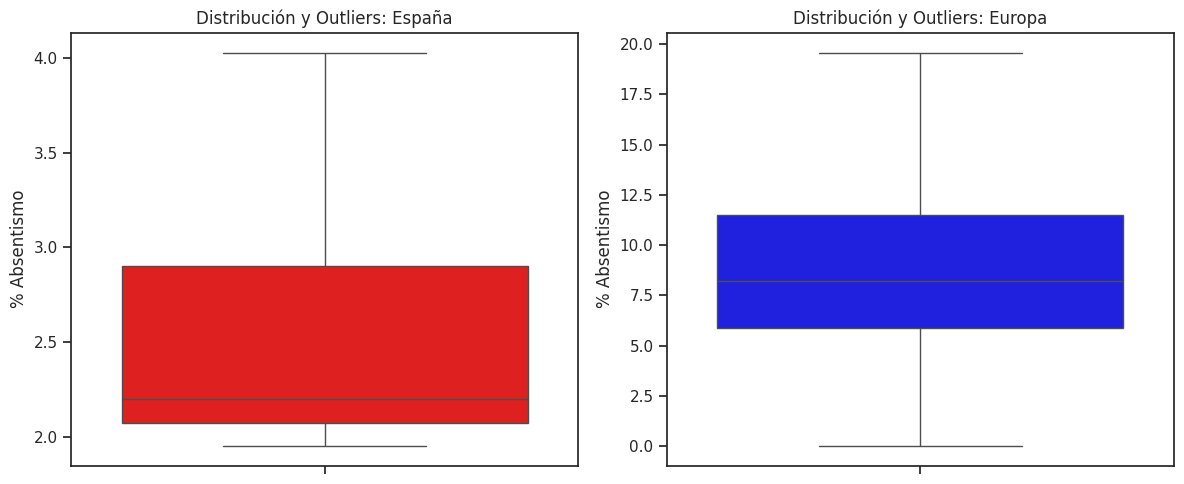

In [30]:
plt.figure(figsize=(12, 5))

# Gráfico para España
plt.subplot(1, 2, 1)
sns.boxplot(y=esp['absentismo_total'], color='red')
plt.title('Distribución y Outliers: España')
plt.ylabel('% Absentismo')

# Gráfico para Europa
plt.subplot(1, 2, 2)
sns.boxplot(y=eur['absentismo'], color='blue')
plt.title('Distribución y Outliers: Europa')
plt.ylabel('% Absentismo')

plt.tight_layout()
plt.show()

## 7.1 Dispersión: absentismo vs. desempleo

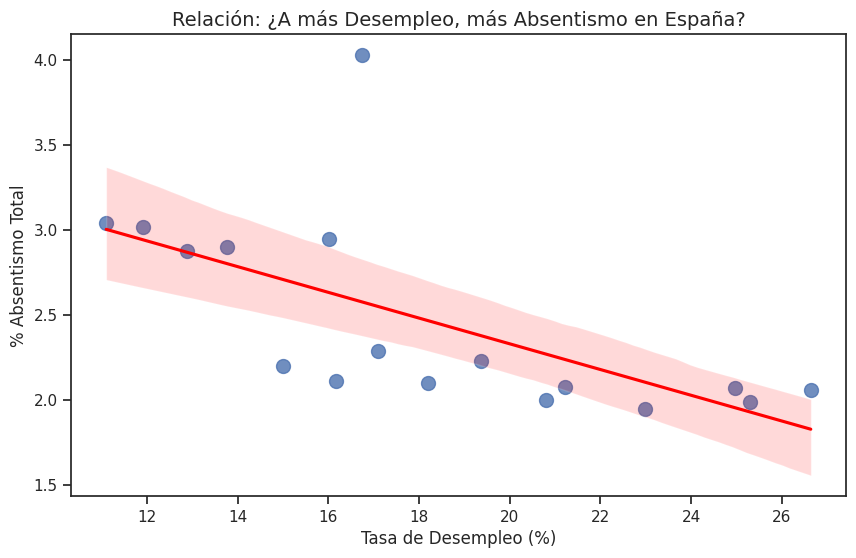

In [31]:
plt.figure(figsize=(10, 6))
# Usamos regplot para que pinte la línea de tendencia automáticamente
sns.regplot(data=esp, x='desempleo', y='absentismo_total', scatter_kws={'s':100}, line_kws={'color':'red'})

plt.title('Relación: ¿A más Desempleo, más Absentismo en España?', fontsize=14)
plt.xlabel('Tasa de Desempleo (%)')
plt.ylabel('% Absentismo Total')
plt.show()

# 8. Análisis temporal

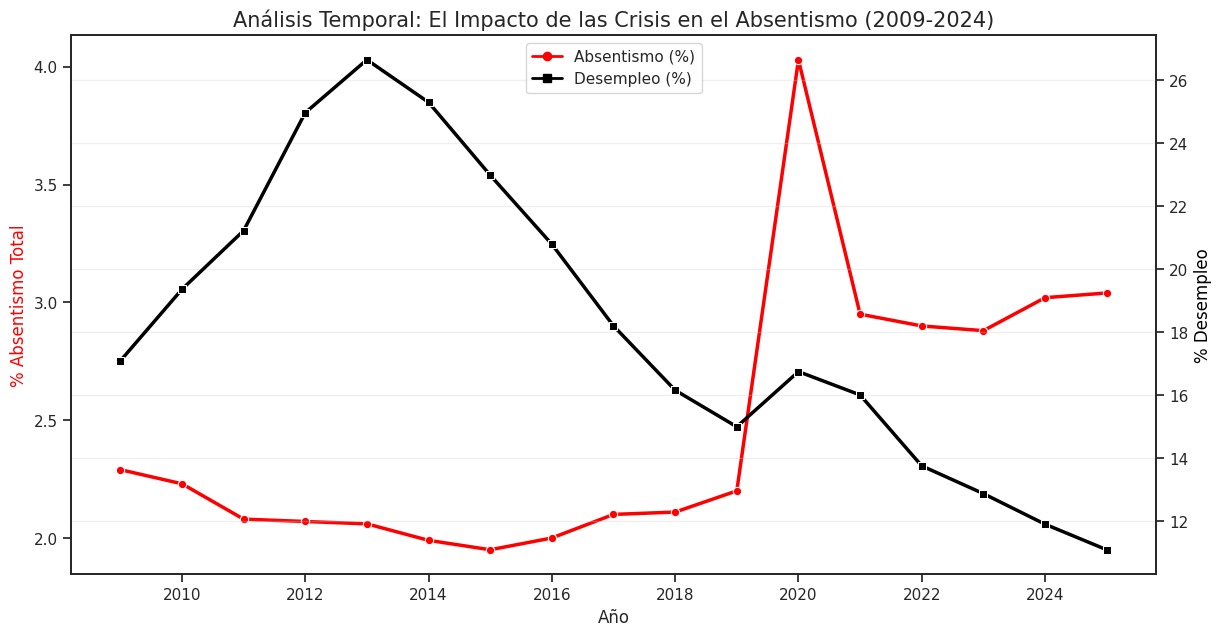

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el gráfico de líneas (Time Series)
plt.figure(figsize=(14, 7))

# Línea 1: Absentismo (usamos un eje para que se vea bien la escala)
ax1 = sns.lineplot(data=esp, x='año', y='absentismo_total', marker='o', color='red', label='Absentismo (%)', linewidth=2.5)
plt.ylabel('% Absentismo Total', color='red', fontsize=12)

# Línea 2: Desempleo (creamos un segundo eje Y porque los valores son más grandes)
ax2 = ax1.twinx()
sns.lineplot(data=esp, x='año', y='desempleo', marker='s', color='black', label='Desempleo (%)', linewidth=2.5, ax=ax2)
plt.ylabel('% Desempleo', color='black', fontsize=12)

# Personalización
plt.title('Análisis Temporal: El Impacto de las Crisis en el Absentismo (2009-2024)', fontsize=15)
ax1.set_xlabel('Año', fontsize=12)
ax1.get_legend().remove() # Limpiamos leyendas duplicadas
ax2.get_legend().remove()
plt.grid(True, alpha=0.3)

# Añadimos una leyenda manual para que quede limpia
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='red', lw=2, marker='o'),
                Line2D([0], [0], color='black', lw=2, marker='s')]
plt.legend(custom_lines, ['Absentismo (%)', 'Desempleo (%)'], loc='upper center')

plt.show()

## 8.1 Dispersión: absentismo vs. coste laboral

# 9. Distribución de densidad

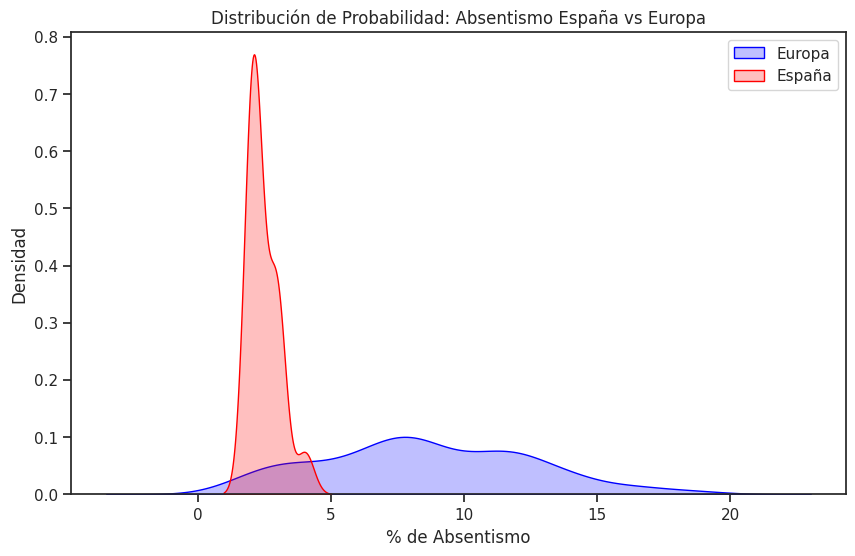

In [34]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=eur, x='absentismo', fill=True, color="blue", label="Europa")
sns.kdeplot(data=esp, x='absentismo_total', fill=True, color="red", label="España")
plt.title('Distribución de Probabilidad: Absentismo España vs Europa')
plt.xlabel('% de Absentismo')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# 10. Segmentación por región

/tmp/ipykernel_4411/2022302164.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=eur, x='region', y='absentismo', palette='viridis', ci=None)
/tmp/ipykernel_4411/2022302164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eur, x='region', y='absentismo', palette='viridis', ci=None)


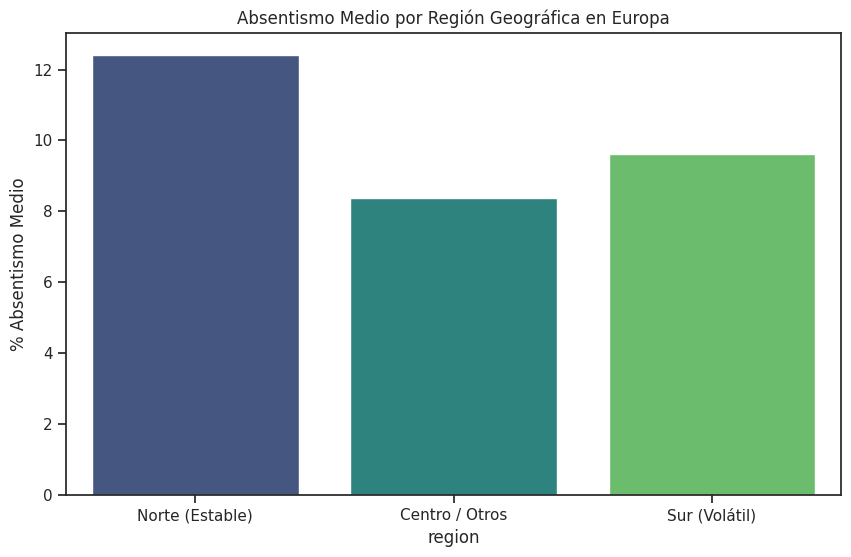

In [35]:
# Definimos los grupos según el comportamiento histórico del mercado laboral
norte = ['Denmark', 'Finland', 'Norway', 'Sweden', 'Netherlands', 'Germany', 'Austria']
sur = ['Spain', 'Italy', 'Portugal', 'Greece', 'Cyprus']

def categorizar_region(pais):
    if pais in norte: return 'Norte (Estable)'
    if pais in sur: return 'Sur (Volátil)'
    return 'Centro / Otros'

# Creamos la nueva variable en el dataset de Europa
eur['region'] = eur['pais'].apply(categorizar_region)

plt.figure(figsize=(10, 6))
sns.barplot(data=eur, x='region', y='absentismo', palette='viridis', ci=None)
plt.title('Absentismo Medio por Región Geográfica en Europa')
plt.ylabel('% Absentismo Medio')
plt.show()

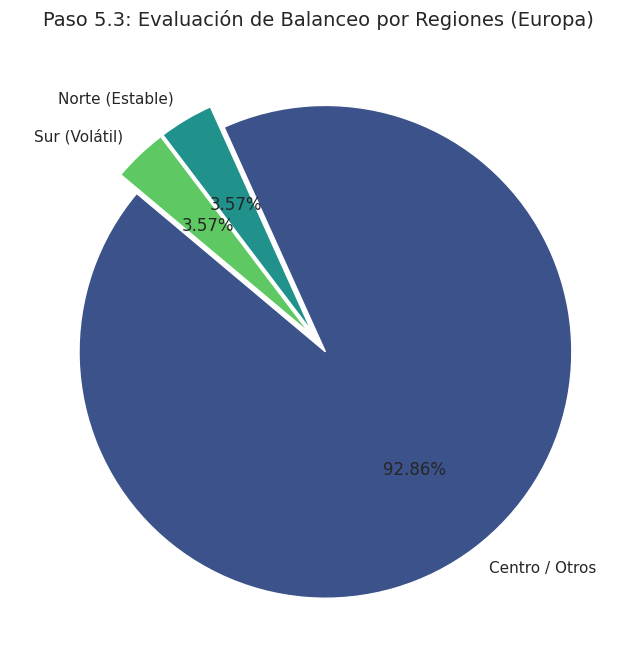

Distribución de registros por región:
region
Centro / Otros     442
Norte (Estable)     17
Sur (Volátil)       17
Name: count, dtype: int64


In [36]:
# 1. Contamos cuántos registros hay por región
counts = eur['region'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.2f%%', startangle=140,
        colors=sns.color_palette('viridis', len(counts)), explode=[0.05]*len(counts))

plt.title('Paso 5.3: Evaluación de Balanceo por Regiones (Europa)', fontsize=14)
plt.show()

# Imprimimos los valores exactos para el Word
print("Distribución de registros por región:")
print(counts)

## 10.1 Codificación ordinal de región

In [37]:
# Codificación ordinal de la variable region
mapping = {'Sur (Volátil)': 0, 'Centro / Otros': 1, 'Norte (Estable)': 2}
eur['region_codificada'] = eur['region'].map(mapping)

print(" Variables codificadas y listas para el modelo.")
print(eur[['pais', 'region', 'region_codificada']].head())

✅ Variables codificadas y listas para el modelo.
      pais           region  region_codificada
0  Austria  Norte (Estable)                  2
1  Austria  Norte (Estable)                  2
2  Austria  Norte (Estable)                  2
3  Austria  Norte (Estable)                  2
4  Austria  Norte (Estable)                  2


In [38]:
eur.head()

,pais,año,empleo,desempleo,actividad,absentismo,parados_larga_dur,horas_hab_trabajadas,poblacion_neet,empleo_yoy,desempleo_yoy,actividad_yoy,absentismo_yoy,parados_larga_dur_yoy,horas_hab_trab_yoy,poblacion_neet_yoy,region,region_codificada
0,Austria,2009,73.4,4.1,77.5,11.88,25.8,38,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Norte (Estable),2
1,Austria,2010,73.9,3.8,77.7,11.70,30.5,38,9.5,"0,68%","-7,32%","0,26%","-1,47%","18,22%","-0,65%","-5,00%",Norte (Estable),2
2,Austria,2011,74.2,3.6,77.8,11.55,31.3,38,8.9,"0,41%","-5,26%","0,13%","-1,28%","2,62%","-0,20%","-6,32%",Norte (Estable),2
3,Austria,2012,74.4,3.9,78.3,12.00,29.6,38,8.6,"0,27%","8,33%","0,64%","3,90%","-5,43%","-0,53%","-3,37%",Norte (Estable),2
4,Austria,2013,74.6,4.3,78.9,12.33,28.9,37,9.0,"0,27%","10,26%","0,77%","2,71%","-2,36%","-0,99%","4,65%",Norte (Estable),2


In [39]:
eur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pais                   476 non-null    object 
 1   año                    476 non-null    int64  
 2   empleo                 476 non-null    float64
 3   desempleo              476 non-null    float64
 4   actividad              476 non-null    float64
 5   absentismo             476 non-null    float64
 6   parados_larga_dur      476 non-null    float64
 7   horas_hab_trabajadas   476 non-null    int64  
 8   poblacion_neet         476 non-null    float64
 9   empleo_yoy             448 non-null    object 
 10  desempleo_yoy          448 non-null    object 
 11  actividad_yoy          448 non-null    object 
 12  absentismo_yoy         448 non-null    object 
 13  parados_larga_dur_yoy  448 non-null    object 
 14  horas_hab_trab_yoy     448 non-null    object 
 15  poblac

# 11. Análisis de outliers — España

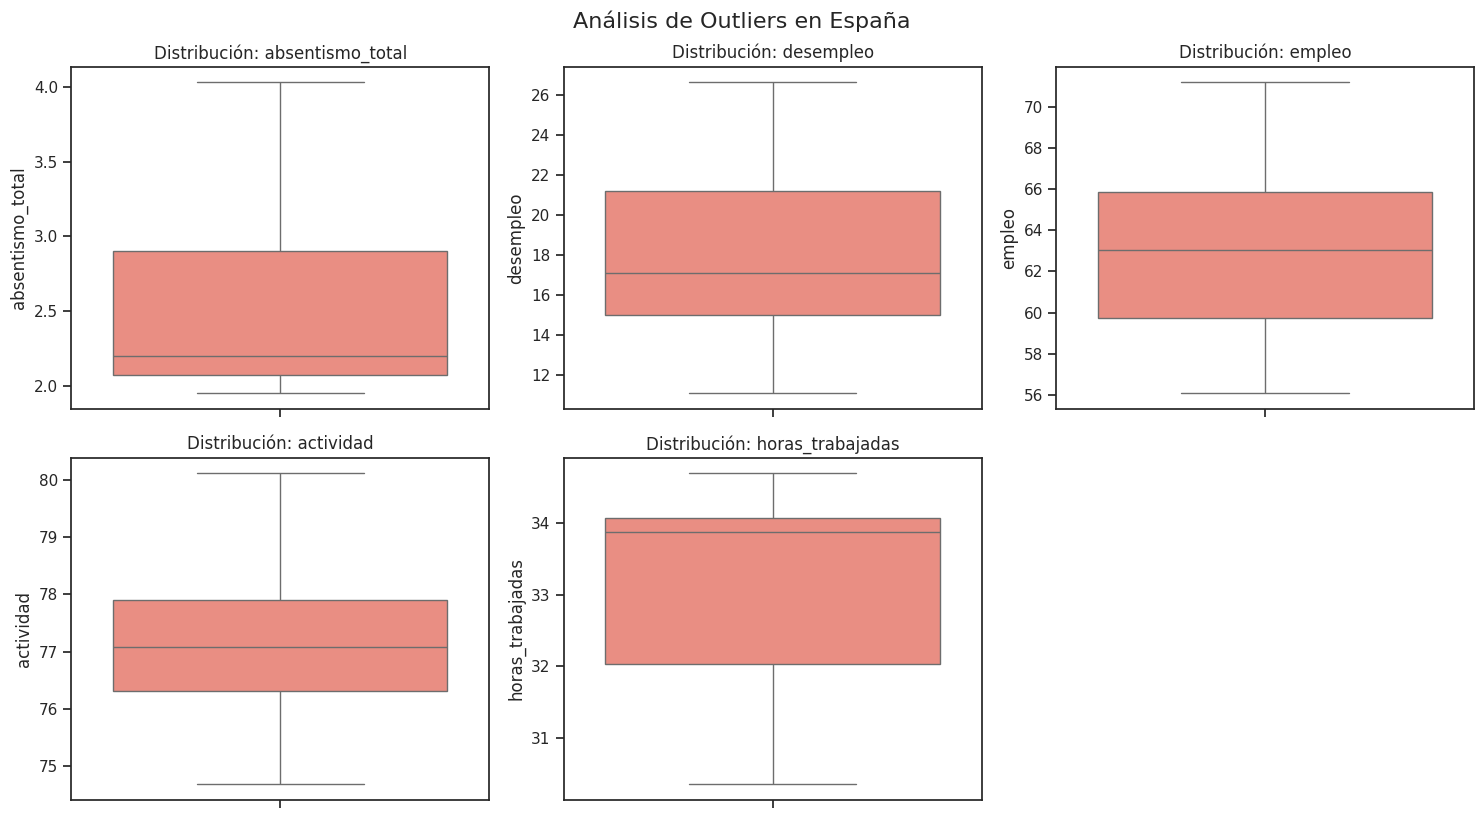

In [40]:
# Lista de variables numéricas de España
vars_esp = ['absentismo_total', 'desempleo', 'empleo', 'actividad', 'horas_trabajadas']

plt.figure(figsize=(15, 8))
for i, var in enumerate(vars_esp, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=esp[var], color='salmon')
    plt.title(f'Distribución: {var}')

plt.tight_layout()
plt.suptitle('Análisis de Outliers en España', y=1.02, fontsize=16)
plt.show()

# 12. Análisis de outliers — Europa

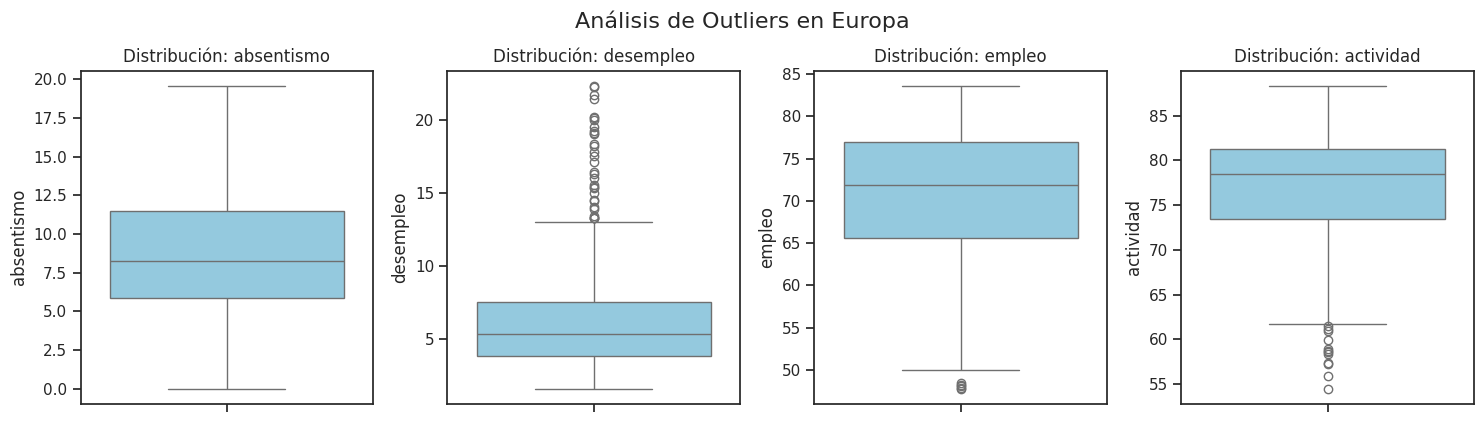

In [41]:
# Lista de variables numéricas de Europa
vars_eur = ['absentismo', 'desempleo', 'empleo', 'actividad']

plt.figure(figsize=(15, 4))
for i, var in enumerate(vars_eur, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=eur[var], color='skyblue')
    plt.title(f'Distribución: {var}')

plt.tight_layout()
plt.suptitle('Análisis de Outliers en Europa', y=1.05, fontsize=16)
plt.show()

## 12.1 Absentismo por tramos de desempleo

## 12.2 Dispersión: absentismo vs. horas trabajadas

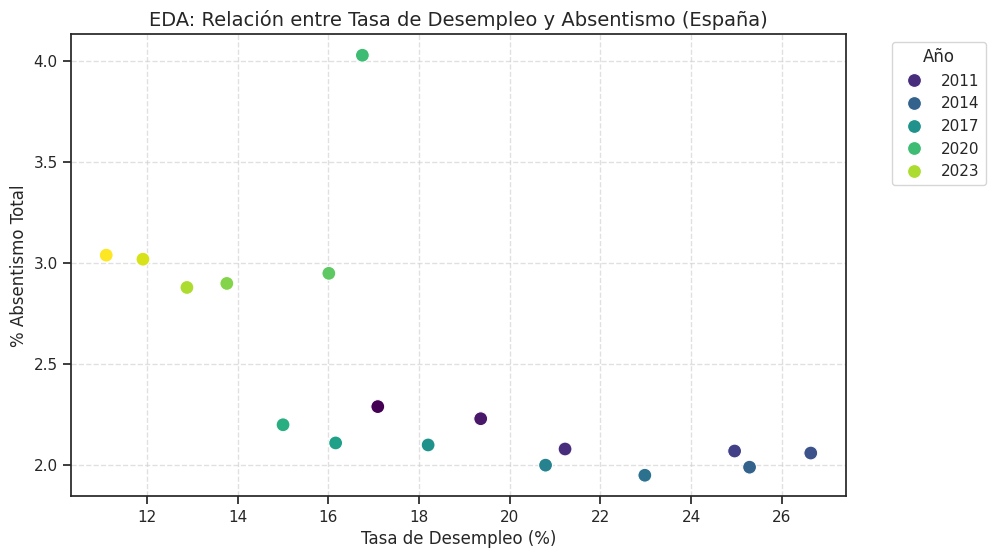

In [44]:
plt.figure(figsize=(10, 6))
# Gráfico de dispersión puro
sns.scatterplot(data=esp, x='desempleo', y='absentismo_total',
                hue='año', palette='viridis', s=100)

plt.title('EDA: Relación entre Tasa de Desempleo y Absentismo (España)', fontsize=14)
plt.xlabel('Tasa de Desempleo (%)')
plt.ylabel('% Absentismo Total')
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 13. Variación interanual (YoY)

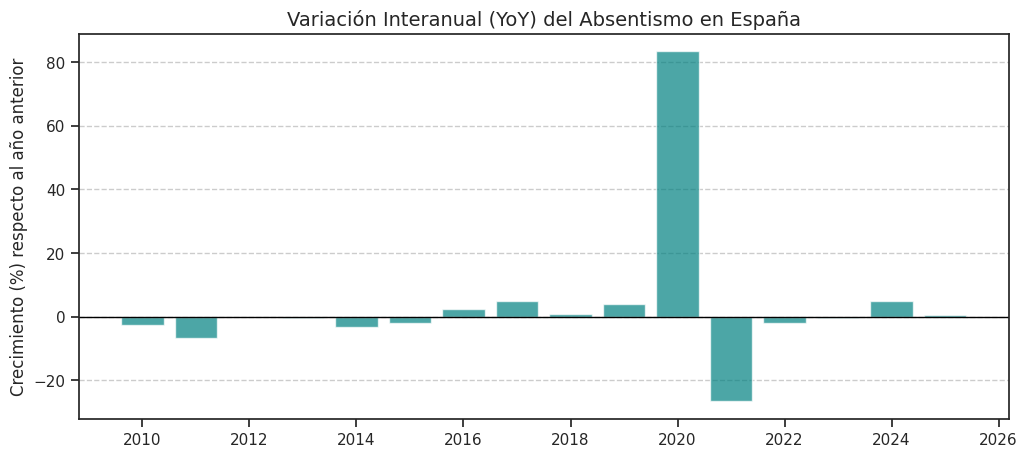

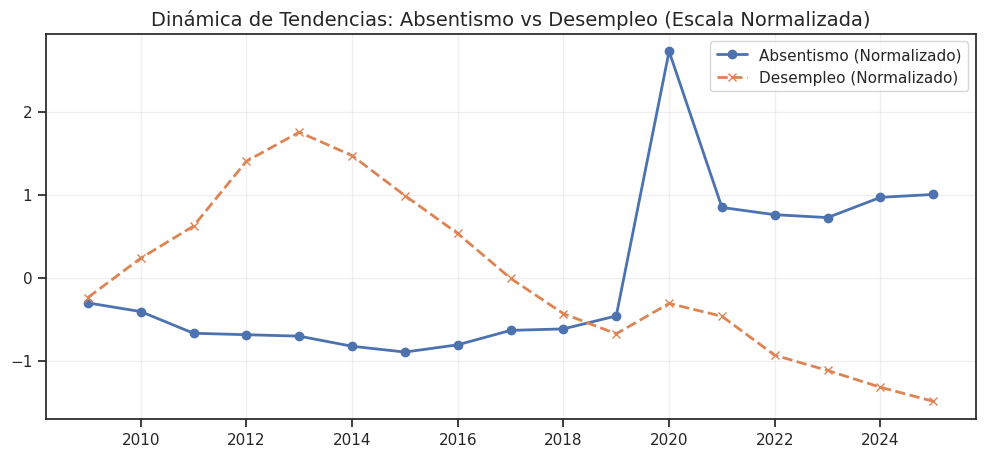

In [45]:
import numpy as np

# Clean and convert 'absentismo_total_yoy' to numeric
esp['absentismo_total_yoy'] = esp['absentismo_total_yoy'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
esp['absentismo_total_yoy'] = pd.to_numeric(esp['absentismo_total_yoy'], errors='coerce')

# 1. Gráfico de Variación Interanual (Crecimiento %)
plt.figure(figsize=(12, 5))
plt.bar(esp['año'], esp['absentismo_total_yoy'], color='teal', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.title('Variación Interanual (YoY) del Absentismo en España', fontsize=14)
plt.ylabel('Crecimiento (%) respecto al año anterior')
plt.grid(axis='y', linestyle='--')
plt.show()

# 2. Comparativa de Tendencias Normalizadas (Z-Score)
# Esto pone ambas variables en la misma escala (media 0, desviación 1)
esp_norm = (esp[['absentismo_total', 'desempleo']] - esp[['absentismo_total', 'desempleo']].mean()) / esp[['absentismo_total', 'desempleo']].std()

plt.figure(figsize=(12, 5))
plt.plot(esp['año'], esp_norm['absentismo_total'], label='Absentismo (Normalizado)', marker='o', linewidth=2)
plt.plot(esp['año'], esp_norm['desempleo'], label='Desempleo (Normalizado)', marker='x', linestyle='--', linewidth=2)
plt.title('Dinámica de Tendencias: Absentismo vs Desempleo (Escala Normalizada)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 14. Anexo D — Análisis de disponibilidad de datos

In [ ]:
# Heatmap de nulos por variable y año — dataset europeo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

vars_check = ['empleo', 'desempleo', 'actividad', 'absentismo',
              'parados_larga_dur', 'horas_hab_trabajadas', 'poblacion_neet']

pivot_nulos = eur.groupby('año')[vars_check].apply(
    lambda g: g.isnull().mean() * 100
)
pivot_nulos.columns = ['Empleo', 'Desempleo', 'Actividad', 'Absentismo',
                       'Paro larga dur.', 'Horas hab.', 'Población NEET']

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_nulos.T, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.4, cbar_kws={'label': '% valores nulos'}, vmin=0, vmax=100)
ax.set_xlabel('Año')
ax.set_ylabel('')
ax.set_title('Figura A1. Porcentaje de valores nulos por variable y año (dataset europeo)\n'
             'Fuente: elaboración propia a partir de Eurostat')
plt.tight_layout()
plt.show()

In [ ]:
# Evolución conjunta: empleo, actividad y horas trabajadas en España
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(esp['año'], esp['empleo'],    marker='o', color='#C0392B', lw=2.5, label='Tasa de empleo (%)')
ax1.plot(esp['año'], esp['actividad'], marker='s', color='#8E44AD', lw=2.5,
         label='Tasa de actividad (%)', linestyle='--')
ax1.set_ylabel('Tasa (%)')
ax1.set_ylim(55, 85)

ax2 = ax1.twinx()
ax2.plot(esp['año'], esp['horas_trabajadas'],     marker='^', color='#E67E22', lw=2.5,
         label='Horas efectivas (h/sem.)')
ax2.plot(esp['año'], esp['horas_hab_trabajadas'], marker='D', color='#27AE60', lw=2.5,
         label='Horas habituales (h/sem.)', linestyle=':')
ax2.set_ylabel('Horas semanales')
ax2.set_ylim(28, 42)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)
ax1.set_xticks(esp['año'])
ax1.set_xticklabels(esp['año'], rotation=45)
ax1.set_title('Figura A2. Evolución de empleo, actividad y horas trabajadas en España (2009-2025)\n'
              'Fuente: elaboración propia a partir de INE')
plt.tight_layout()
plt.show()

# 15. Anexo E — Análisis temporal ampliado de España

In [ ]:
# Paro corta vs. larga duración — área apilada
fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(esp['año'],
             esp['parados_corta_dur'],
             esp['parados_larga_dur'],
             labels=['Paro corta duración (<12 meses)', 'Paro larga duración (≥12 meses)'],
             colors=['#F39C12', '#E74C3C'], alpha=0.8)
ax.set_ylabel('% sobre total de parados')
ax.set_xticks(esp['año'])
ax.set_xticklabels(esp['año'], rotation=45)
ax.legend(loc='upper left')
ax.set_ylim(0, 110)
ax.set_title('Figura A3. Evolución del paro por duración en España (2009-2025)\n'
             'Fuente: elaboración propia a partir de INE-EPA')
plt.tight_layout()
plt.show()

In [ ]:
# Coste laboral (barras) + absentismo total (línea) — eje dual
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(esp['año'] - 0.2, esp['coste_laboral'], width=0.4,
        color='#16A085', alpha=0.8, label='Coste laboral (€/hora)')
ax1.set_ylabel('Coste laboral (€/hora)', color='#16A085')
ax1.tick_params(axis='y', labelcolor='#16A085')

ax2 = ax1.twinx()
ax2.plot(esp['año'], esp['absentismo_total'], marker='o',
         color='#C0392B', lw=2.5, label='Absentismo total (%)')
ax2.fill_between(esp['año'], esp['absentismo_total'], alpha=0.15, color='#C0392B')
ax2.set_ylabel('% Absentismo total', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_xticks(esp['año'])
ax1.set_xticklabels(esp['año'], rotation=45)
ax1.set_title('Figura A4. Evolución del coste laboral y el absentismo en España (2009-2025)\n'
              'Fuente: elaboración propia a partir de INE')
plt.tight_layout()
plt.show()

In [ ]:
# Absentismo total vs. absentismo por enfermedad/accidente
fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(esp['año'], esp['absentismo_total'],   alpha=0.3, color='#C0392B', label='Absentismo total')
ax.fill_between(esp['año'], esp['absentismo_enf_acc'], alpha=0.6, color='#E67E22', label='Por enfermedad/accidente')
ax.plot(esp['año'], esp['absentismo_total'],   color='#C0392B', lw=2.5, marker='o')
ax.plot(esp['año'], esp['absentismo_enf_acc'], color='#E67E22', lw=2.5, marker='s')
ax.set_ylabel('% sobre total de ocupados')
ax.set_xticks(esp['año'])
ax.set_xticklabels(esp['año'], rotation=45)
ax.legend()
ax.set_ylim(0, 5)
ax.set_title('Figura A5. Absentismo total vs. absentismo por enfermedad/accidente en España (2009-2025)\n'
             'Fuente: elaboración propia a partir de INE')
plt.tight_layout()
plt.show()

# 16. Anexo F — Análisis europeo comparado

In [ ]:
# Ranking de absentismo medio por país europeo
import matplotlib.patches as mpatches

media_pais = eur.groupby('pais')['absentismo'].mean().sort_values(ascending=True)
colores_bar = ['#C0392B' if p == 'España' else '#2E86C1' for p in media_pais.index]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(media_pais.index, media_pais.values, color=colores_bar, alpha=0.85)
ax.axvline(media_pais.mean(), color='black', linestyle='--', lw=1.5,
           label=f'Media europea ({media_pais.mean():.1f}%)')
ax.set_xlabel('Absentismo medio (%, 2009-2025)')

for bar, val in zip(bars, media_pais.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)

esp_patch = mpatches.Patch(color='#C0392B', label='España')
eur_patch = mpatches.Patch(color='#2E86C1', label='Resto de países')
media_line = plt.Line2D([0], [0], color='black', linestyle='--',
                        label=f'Media europea ({media_pais.mean():.1f}%)')
ax.legend(handles=[esp_patch, eur_patch, media_line], fontsize=9)
ax.set_title('Figura A6. Ranking de absentismo laboral medio por país europeo (2009-2025)\n'
             'Fuente: elaboración propia a partir de Eurostat')
plt.tight_layout()
plt.show()

In [ ]:
# Evolución del absentismo medio por región europea
region_year = eur.groupby(['año', 'region'])['absentismo'].mean().reset_index()

colores_reg = {
    'Norte (Estable)': '#2E86C1',
    'Sur (Volátil)':   '#C0392B',
    'Centro / Otros':  '#27AE60'
}
markers_reg = {'Norte (Estable)': 'o', 'Sur (Volátil)': 's', 'Centro / Otros': '^'}

fig, ax = plt.subplots(figsize=(12, 6))
for region in region_year['region'].unique():
    d = region_year[region_year['region'] == region]
    ax.plot(d['año'], d['absentismo'],
            marker=markers_reg.get(region, 'o'),
            color=colores_reg.get(region, 'gray'),
            lw=2.5, label=region)

ax.set_ylabel('Absentismo medio (%)')
ax.set_xticks(region_year['año'].unique())
ax.set_xticklabels(region_year['año'].unique(), rotation=45)
ax.legend()
ax.set_ylim(0, 18)
ax.set_title('Figura A7. Evolución del absentismo por región geográfica europea (2009-2025)\n'
             'Fuente: elaboración propia a partir de Eurostat')
plt.tight_layout()
plt.show()

In [ ]:
# Scatter desempleo vs. absentismo en Europa, coloreado por región
fig, ax = plt.subplots(figsize=(10, 7))

for region, color in colores_reg.items():
    d = eur[eur['region'] == region]
    ax.scatter(d['desempleo'], d['absentismo'],
               color=color, alpha=0.55, s=50, label=region,
               edgecolors='white', lw=0.3)

esp_eur = eur[eur['pais'] == 'España']
ax.scatter(esp_eur['desempleo'], esp_eur['absentismo'],
           color='black', s=90, zorder=5, marker='*',
           label='España', edgecolors='#C0392B', lw=1)

ax.set_xlabel('Tasa de desempleo (%)')
ax.set_ylabel('Tasa de absentismo (% empleo)')
ax.legend(markerscale=1.2, fontsize=9)
ax.set_title('Figura A8. Relación desempleo-absentismo en Europa por región (2009-2025)\n'
             'Fuente: elaboración propia a partir de Eurostat')
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap de correlación — dataset europeo
vars_corr_eur = ['empleo', 'desempleo', 'actividad', 'absentismo',
                 'parados_larga_dur', 'poblacion_neet']
labels_eur = ['Empleo', 'Desempleo', 'Actividad', 'Absentismo',
              'Paro larga dur.', 'Pob. NEET']

corr_eur = eur[vars_corr_eur].corr()
corr_eur.index = labels_eur
corr_eur.columns = labels_eur

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_eur, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Figura A9. Matriz de correlación de variables del mercado laboral en Europa (2009-2025)\n'
             'Fuente: elaboración propia a partir de Eurostat')
plt.tight_layout()
plt.show()

In [ ]:
# Distribución de la población NEET por región geográfica
order = ['Norte (Estable)', 'Sur (Volátil)', 'Centro / Otros']
data_list = [eur[eur['region'] == r]['poblacion_neet'].dropna() for r in order]
colors_box = ['#2E86C1', '#C0392B', '#27AE60']

fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(data_list, labels=order, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel('% jóvenes sin empleo ni formación (NEET)')
ax.set_title('Figura A10. Distribución de la población NEET por región geográfica europea (2009-2025)\n'
             'Fuente: elaboración propia a partir de Eurostat')
plt.tight_layout()
plt.show()

In [ ]:
# Exportar datasets finales
eur.to_csv("europa_final.csv", index=False)
esp.to_csv("espana_final.csv", index=False)
print("Datasets exportados correctamente.")